In [10]:
""" Compare against pore water chemistry data of Natalie/Verity
Measurements depths are relative to hollow surface"""
import pandas as pd
import numpy as np
import os
from utils.analysis import vert_interp, get_dissolved_nutrients
from utils.constants import chamber_levels_complete, chamber_list_complete_dict
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from glob import glob
import xarray as xr
#from scipy.stats import pearsonr, spearmanr, chi2, probplot
#from statsmodels.tools import add_constant
#from statsmodels.regression.mixed_linear_model import MixedLM
from scipy.stats import linregress
from matplotlib import rcParams

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

chambers_ordered = {
    'amb': ['07', '06', '20', '13', '08', '17'],
    'elev': ['19', '11', '04', '16', '10']
}
xticklabels = ['TAMB', 'T0.00', 'T2.25','T4.50', 'T6.75', 'T9.00', 
               'T0.00CO2', 'T2.25CO2', 'T4.5CO2', 'T6.75CO2', 'T9.00CO2']

# which depth of observation to look at, pick from depth_list
depth_list = ['0.0', '0.3', '0.5', '1.0', '2.0', '3.0']
DEPTH = 0.3

In [11]:
data = get_dissolved_nutrients(DEPTH)

In [ ]:
# Collect modeled dissolved nutrients, layersize
year_range = range(2015, 2022)
plot_list = list(chamber_levels_complete.keys())
prefix_list = ['20231116', 'UQ_20231118', 'UQ_20240107', 'UQ_20240112']
ens_list = [None, 3067, 1485, 1944]
name_list = ['ELM-OLD', 'ELM-OLD$_{optim}$', 'ELM-MYCI', 'ELM-MYCI$_{optim}$']
color_list = ['#05dbfc', '#1b249e', '#ffa500', '#ff0000']

tvec = pd.date_range('2015-01-01', '2021-12-31')
tvec = tvec[(tvec.month != 2) | (tvec.day != 29)]
sims_data = {}

for prefix, ensemble_id in zip(prefix_list, ens_list):
    sims_data[(prefix, 'SMIN_NO3_vr')] = \
        pd.DataFrame(np.nan, 
                    columns = pd.MultiIndex.from_product([['hummock', 'hollow', 'average'],
                                                            plot_list]),
                    index = tvec)
    sims_data[(prefix, 'SMIN_NH4_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SMINN_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    sims_data[(prefix, 'SOLUTIONP_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()
    # sims_data[(prefix, 'LABILEP_vr')] = sims_data[(prefix, 'SMIN_NO3_vr')].copy()

    for plot in plot_list:
        if not "UQ" in prefix:
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'spruce_treatments', 
                                f'plot{plot}_US-SPR_ICB20TRCNPRDCTCBC', 'run')
        else:
            temp = f'P{plot}'
            rundir = os.path.join(os.environ['E3SM_ROOT'], 'output', 'UQ',
                                f'{prefix}_US-SPR_ICB20TRCNPRDCTCBC', f'g{ensemble_id:05d}', 
                                f'{chamber_list_complete_dict[temp]}')

        flist = sorted(glob(rundir + "/*.h1.*.nc"))
        flist = [f for f in flist if \
                int(f.split('/')[-1].split('.')[-2].split('-')[0]) in year_range]
        hr = xr.open_mfdataset(flist)

        for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']: # , 'LABILEP_vr']:
            LEVGRND = np.array([0.007100635, 0.027925, 0.06225858, 0.1188651, 0.2121934,
                                0.3660658, 0.6197585, 1.038027, 1.727635, 2.864607, 4.739157,
                                7.829766, 12.92532, 21.32647, 35.17762])
            LEVGRND_I = np.append(np.insert(
                (LEVGRND[1:] + LEVGRND[:-1])*0.5, 0, 0
            ), LEVGRND[-1] + 0.5 * (LEVGRND[-1] - LEVGRND[-2]))
            THICKNESS = np.diff(LEVGRND_I)

            target_nodes = [DEPTH]
            input_nodes = LEVGRND
            target_single_level = True

            for col, colname in enumerate(['hummock', 'hollow']):
                input_data = hr[var][:, :, col].values / hr['H2OSOI'][:, :, col].values

                result = vert_interp(target_nodes, input_nodes, input_data, 
                                    target_single_level)
                sims_data[(prefix, var)].loc[:, (colname, plot)] = result[:, 0]
        hr.close()

    for var in ['SMINN_vr', 'SMIN_NH4_vr', 'SMIN_NO3_vr', 'SOLUTIONP_vr']: # , 'LABILEP_vr']:
        sims_data[(prefix, var)].loc[:, 'average'] = \
            sims_data[(prefix, var)].loc[:, 'hummock'].values * 0.64 + \
            sims_data[(prefix, var)].loc[:, 'hollow'].values * 0.36

In [13]:
# Compare the temporal trend in each chamber between the observation and simulated values
collect_mean = pd.DataFrame(np.nan,
                             index = chambers_ordered['amb'] + chambers_ordered['elev'],
                             columns = pd.MultiIndex.from_product([['NH4','NO3','SRP'],
                                                                   ['Obs'] + prefix_list]))

collect_trend = pd.DataFrame(np.nan,
                             index = chambers_ordered['amb'] + chambers_ordered['elev'],
                             columns = pd.MultiIndex.from_product([['NH4','NO3','SRP'],
                                                                   ['Obs'] + prefix_list]))
collect_trend_p = collect_trend.copy()

for sim_name, obs_name in zip(['SMIN_NH4_vr','SMIN_NO3_vr','SOLUTIONP_vr'],
                              ['NH4','NO3','SRP']):

    # observed data
    obs_data_var = data[['PLOT', 'DATE', obs_name]
                        ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

    day_since_begin = (obs_data_var.index - obs_data_var.index[0]).days
    for col in chambers_ordered['amb'] + chambers_ordered['elev']:

        filt = ~np.isnan(obs_data_var[col].values)

        collect_mean.loc[col,(obs_name, 'Obs')] = np.mean(obs_data_var[col].values[filt])

        res = linregress(day_since_begin[filt], obs_data_var[col].values[filt])
        collect_trend.loc[col, (obs_name, 'Obs')] = res.slope
        collect_trend_p.loc[col, (obs_name, 'Obs')] = res.pvalue

    for p, (prefix, name) in enumerate(zip(prefix_list, name_list)):

        # growing season simulated data
        sims_data_var = sims_data[(prefix, sim_name)]
        sims_data_var = sims_data_var.loc[:, 'hollow']

        sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                         columns = obs_data_var.columns)
        for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
            sims_data_matched.loc[:, plot] = \
                sims_data_var.loc[obs_data_var.index, plot]

        for col in chambers_ordered['amb'] + chambers_ordered['elev']:
            filt = ~np.isnan(obs_data_var[col].values)

            collect_mean.loc[col,(obs_name, name)] = np.mean(sims_data_matched[col].values[filt])

            res = linregress(day_since_begin[filt], sims_data_matched[col].values[filt])
            collect_trend.loc[col, (obs_name, name)] = res.slope
            collect_trend_p.loc[col, (obs_name, name)] = res.pvalue
collect_mean.index = xticklabels
collect_trend.index = xticklabels
collect_trend_p.index = xticklabels

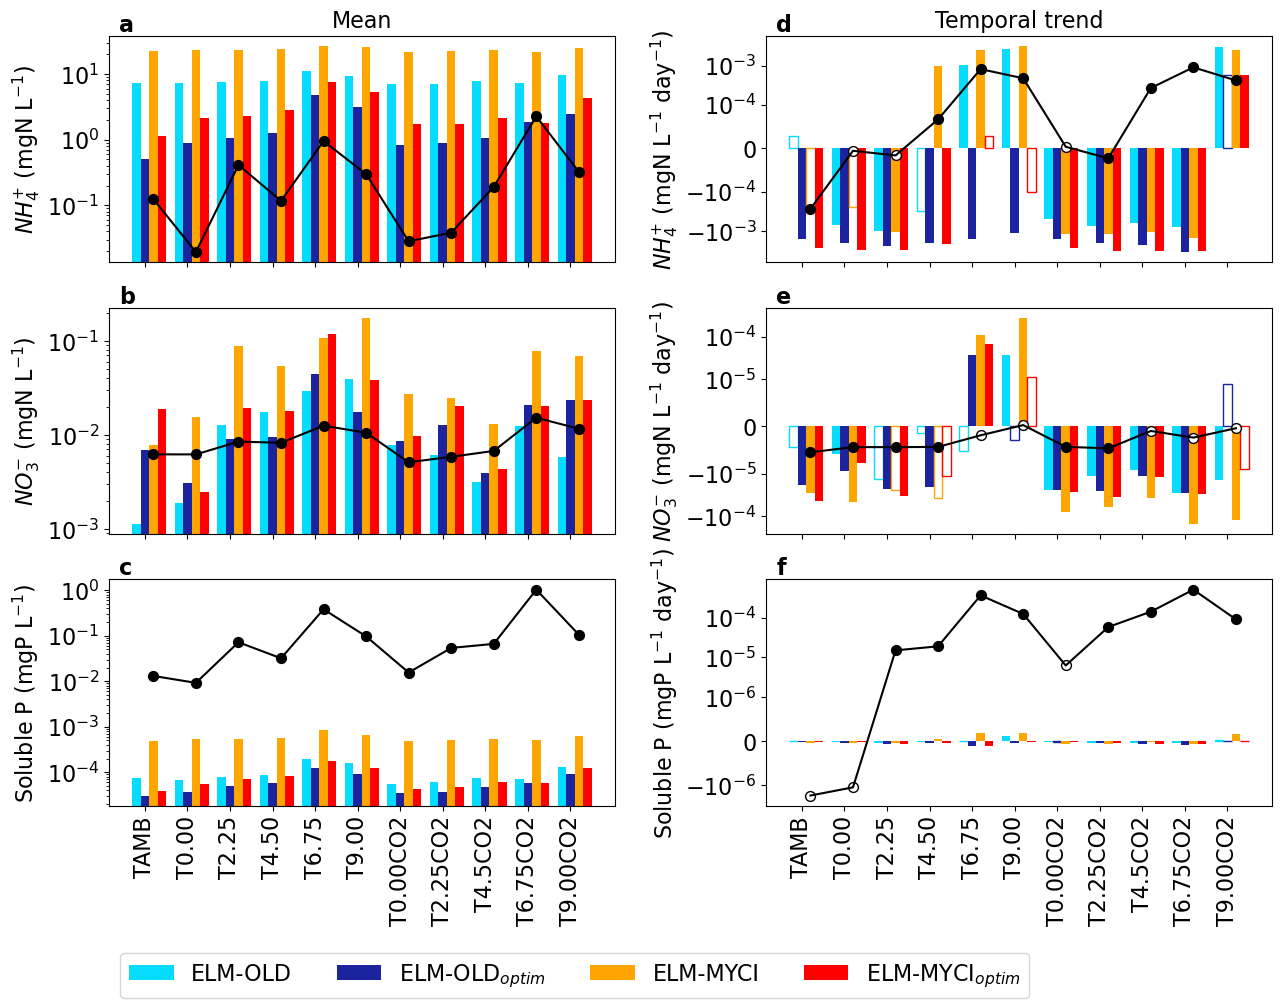

In [14]:
def plot_trends_with_significance(ax, trend_df, pval_df, significance_level=0.05, 
                                  colors = ['#05dbfc', '#1b249e', '#ffa500', '#ff0000']
):
    """
    Plot trends as bars with hollow style for non-significant trends.
    
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes object to plot on
    trend_df : pandas.DataFrame
        DataFrame containing trend values
    pval_df : pandas.DataFrame, or None to skip
        DataFrame containing corresponding p-values
    significance_level : float, optional
        P-value threshold for significance (default: 0.05)
    colors : list, optional
        List of colors for each column
    """
    
    bar_width = 0.2
    x = np.arange(len(trend_df.index))
    
    for i, (col, color) in enumerate(zip(trend_df.columns, colors)):
        trends = trend_df[col]
        bars = ax.bar(x + i*bar_width, trends, bar_width, 
                      label=col, color=color)

        if not pval_df is None:
            # Make non-significant bars hollow
            pvals = pval_df[col]
            for bar, pval in zip(bars, pvals):
                if pval > significance_level:
                    bar.set_facecolor('none')
                    bar.set_edgecolor(color)

    # Customize the plot
    ax.set_xticks(x + bar_width)
    ax.set_xticklabels(trend_df.index, rotation=90)

    return ax


labs = 'abcdefghijklmn'
fig, axes = plt.subplots(3, 2, figsize = (15, 10), sharex = True, sharey = False)
fig.subplots_adjust(wspace = 0.3)
for i, obs_name in enumerate(['NH4','NO3']):
    temp = collect_mean.loc[:,obs_name].loc[:, name_list]
    plot_trends_with_significance(axes[i,0], temp, None)

    temp = collect_mean.loc[:, (obs_name,'Obs')]
    axes[i,0].plot(np.arange(temp.shape[0]) + 0.4, temp, '-k')
    axes[i,0].scatter(np.arange(temp.shape[0]) + 0.4, temp, s = 50, color = 'k', facecolor = 'k')

    if i == 0:
        axes[i,0].set_ylabel('$NH_4^{+}$ (mgN L$^{-1}$)')
        axes[i,0].set_title('Mean')
    elif i == 1:
        axes[i,0].set_ylabel('$NO_3^{-}$ (mgN L$^{-1}$)')
    axes[i,0].text(0.02, 1.02, labs[i], transform = axes[i,0].transAxes, 
                   fontdict = {'weight': 'bold'})
    axes[i,0].set_yscale('log')

# scale the modeled values by 1e3 for SRP because it is too small
obs_name = 'SRP'
temp = collect_mean.loc[:,obs_name].loc[:, name_list].copy()
plot_trends_with_significance(axes[2,0], temp, None)
temp = collect_mean.loc[:, (obs_name,'Obs')]
axes[2,0].plot(np.arange(temp.shape[0]) + 0.4, temp, '-k')
axes[2,0].scatter(np.arange(temp.shape[0]) + 0.4, temp, s = 50, color = 'k', facecolor = 'k')
axes[2,0].set_ylabel('Soluble P (mgP L$^{-1}$)') # $PO_4^{3-}$
axes[2,0].text(0.02, 1.02, labs[2], transform = axes[2,0].transAxes, 
                fontdict = {'weight': 'bold'})
axes[2,0].set_yscale('log')

for i, obs_name in enumerate(['NH4','NO3']):
    temp = collect_trend.loc[:,obs_name].loc[:, name_list]
    temp_p = collect_trend_p.loc[:,obs_name].loc[:, name_list]
    plot_trends_with_significance(axes[i,1], temp, temp_p)

    temp = collect_trend.loc[:, (obs_name,'Obs')]
    temp_p = collect_trend_p.loc[:, (obs_name,'Obs')]
    x = np.arange(temp.shape[0]) + 0.4
    axes[i,1].plot(x, temp, '-k')
    axes[i,1].scatter(x[temp_p <= 0.05], temp[temp_p <= 0.05], s = 50, color = 'k', facecolor = 'k')
    axes[i,1].scatter(x[temp_p > 0.05], temp[temp_p > 0.05], s = 50, color = 'k', facecolor = 'w')

    if i == 0:
        axes[i,1].set_ylabel('$NH_4^{+}$ (mgN L$^{-1}$ day$^{-1}$)')
        axes[i,1].set_title('Temporal trend')
    elif i == 1:
        axes[i,1].set_ylabel('$NO_3^{-}$ (mgN L$^{-1}$ day$^{-1}$)')
    axes[i,1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
    axes[i,1].text(0.02, 1.02, labs[i+3], transform = axes[i,1].transAxes, 
                   fontdict = {'weight': 'bold'})
    if i == 0:
        axes[i,1].set_yscale('symlog', linthresh = 1e-4)
    else:
        axes[i,1].set_yscale('symlog', linthresh = 1e-5)
axes[0,0].legend(ncol = 5, loc = 'upper left', bbox_to_anchor = (0, -3))

# scale the modeled values by 1e3 for SRP because it is too small
obs_name = 'SRP'
temp = collect_trend.loc[:,obs_name].loc[:, name_list].copy()
temp_p = collect_trend_p.loc[:,obs_name].loc[:, name_list]
plot_trends_with_significance(axes[2,1], temp, temp_p)

temp = collect_trend.loc[:, (obs_name,'Obs')]
temp_p = collect_trend_p.loc[:, (obs_name,'Obs')]
x = np.arange(temp.shape[0]) + 0.4
axes[2,1].plot(x, temp, '-k')
axes[2,1].scatter(x[temp_p <= 0.05], temp[temp_p <= 0.05], s = 50, color = 'k', facecolor = 'k')
axes[2,1].scatter(x[temp_p > 0.05], temp[temp_p > 0.05], s = 50, color = 'k', facecolor = 'w')

axes[2,1].set_ylabel('Soluble P (mgP L$^{-1}$ day$^{-1}$)') # $PO_4^{3-}$
axes[2,1].ticklabel_format(axis='y', style='sci', scilimits=(-4, 4))
axes[2,1].text(0.02, 1.02, labs[2+3], transform = axes[2,1].transAxes, 
                fontdict = {'weight': 'bold'})
axes[2,1].set_yscale('symlog', linthresh = 1e-6)

/tmp/ipykernel_604398/3886629100.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_604398/3886629100.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_604398/3886629100.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('magma_r')
/tmp/ipykernel_604398/3886629100.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 an

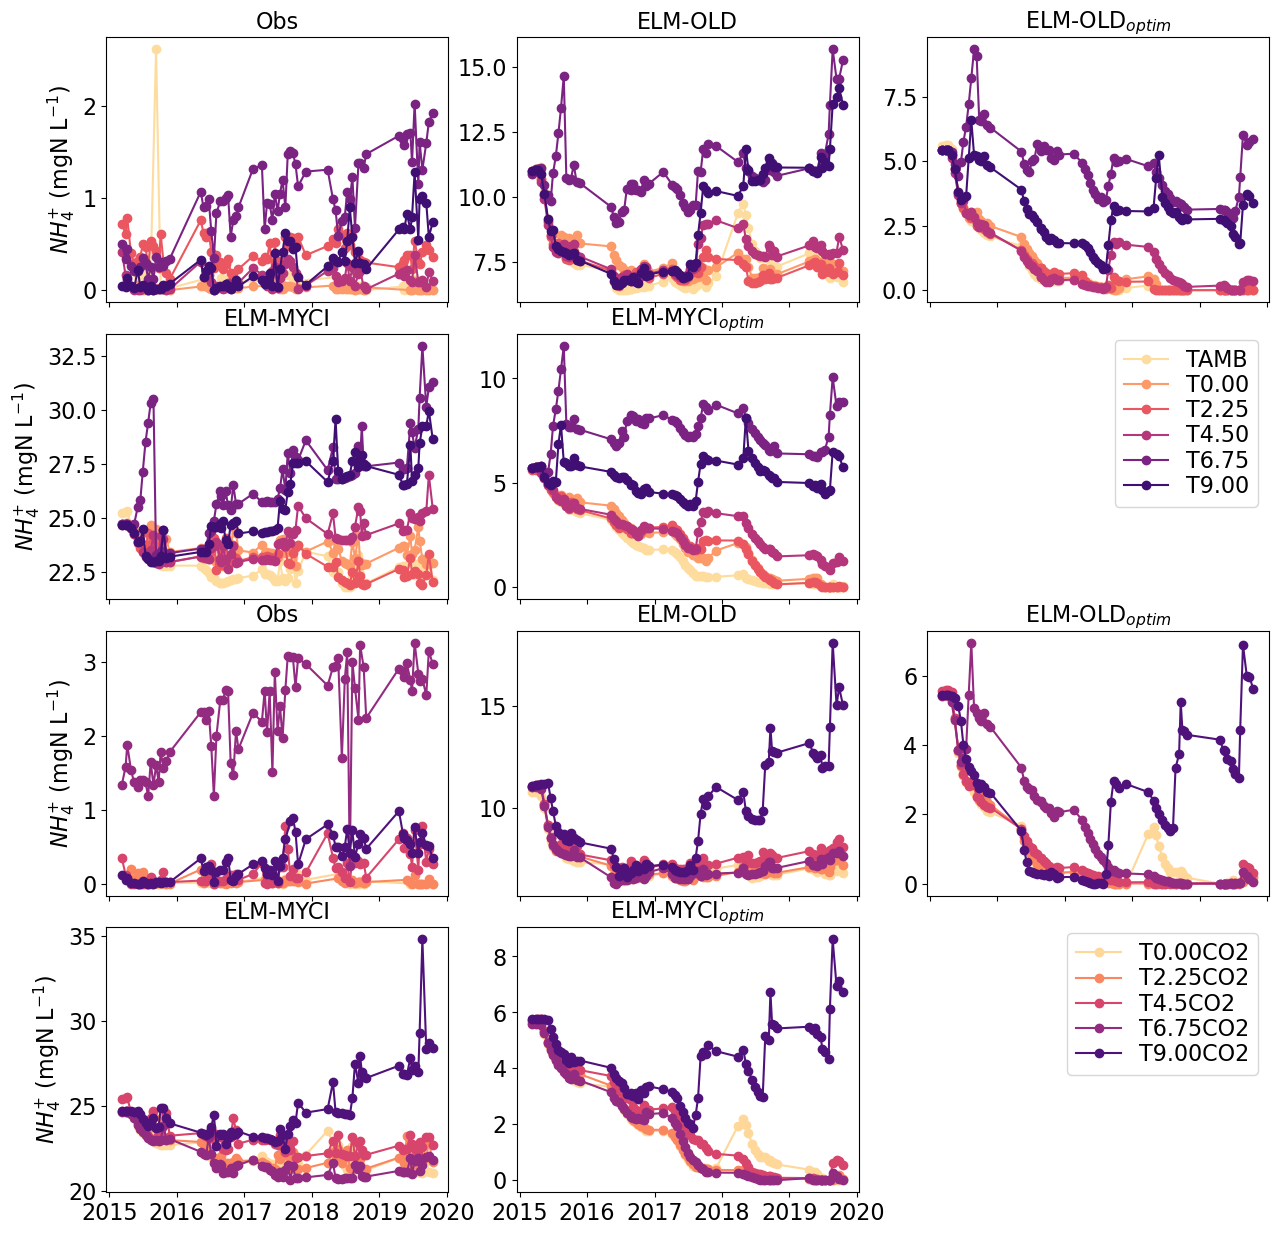

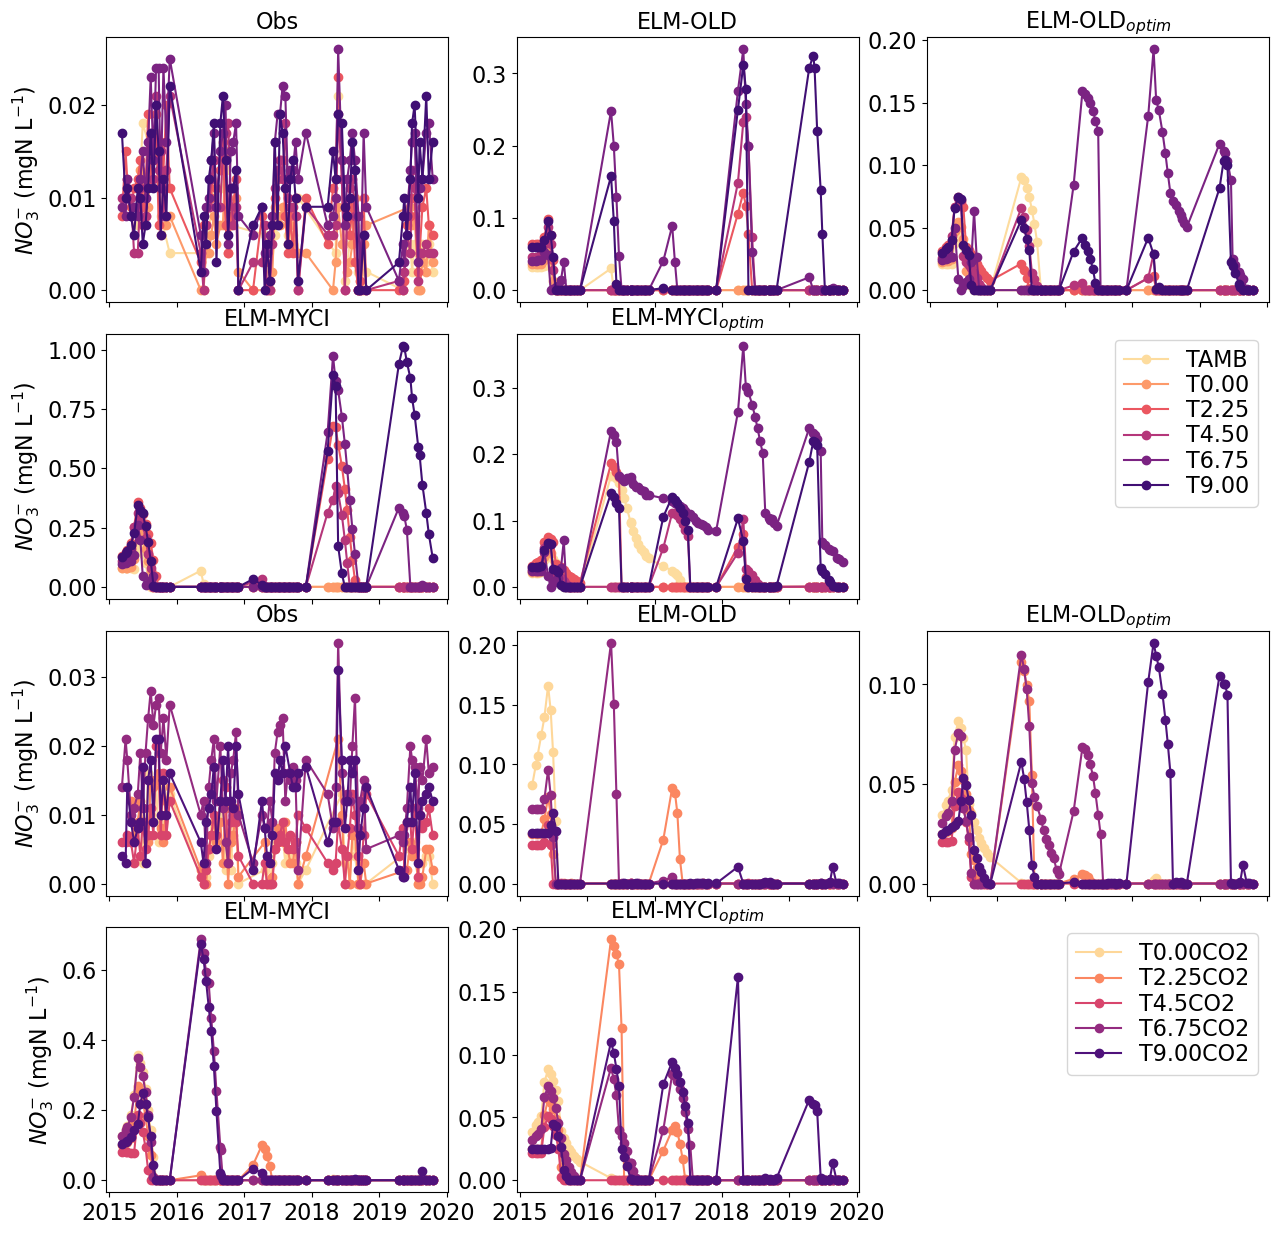

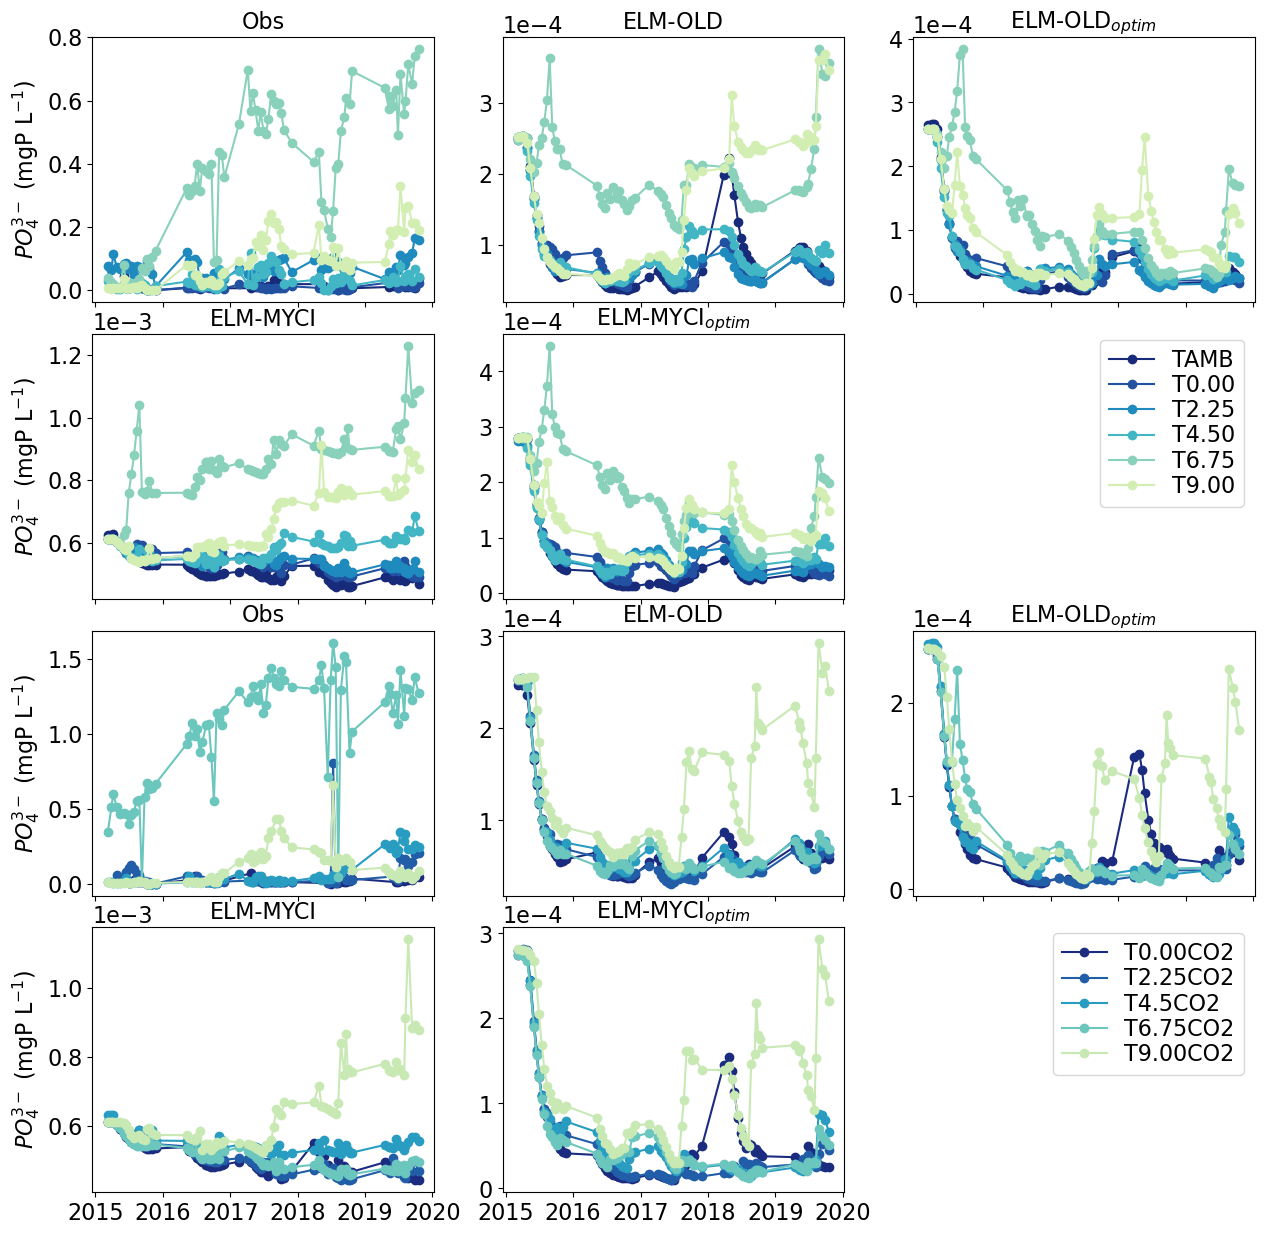

In [15]:
for sim_name, obs_name in zip(['SMIN_NH4_vr','SMIN_NO3_vr','SOLUTIONP_vr'],
                              ['NH4','NO3','SRP']):
    fig, axes = plt.subplots(4, 3, figsize = (15, 15),
                             sharex = True, sharey = False)
    fig.subplots_adjust(hspace = 0.12)

    if obs_name == 'NH4':
        ylabel = '$NH_4^{+}$ (mgN L$^{-1}$)'
    elif obs_name == 'NO3':
        ylabel = '$NO_3^{-}$ (mgN L$^{-1}$)'
    else:
        ylabel = '$PO_4^{3-}$ (mgP L$^{-1}$)'

    for j, co2 in enumerate(['amb', 'elev']):
        if co2 == 'amb':
            label_list = xticklabels[:6]
        else:
            label_list = xticklabels[6:]

        if obs_name == 'SRP':
            cmap = get_cmap('YlGnBu_r')
        else:
            cmap = get_cmap('magma_r')
        clist = [ cmap((i+0.5) / (len(label_list)+1)) for i in range(len(label_list)) ]

        # observation
        ax = axes.flat[j*6]
        count = 0
        for plot, label in zip(chambers_ordered[co2], label_list):
            ax.plot(data.loc[data['PLOT'] == plot, 'DATE'], 
                    data.loc[data['PLOT'] == plot,  obs_name], 
                    '-o', label = label, color = clist[count])
            count += 1
        ax.set_title('Obs')
        ax.set_ylabel(ylabel)

        obs_data_var = data[['PLOT', 'DATE', obs_name]
                            ].set_index(['DATE', 'PLOT']).iloc[:,0].dropna().unstack()

        # simulations
        for p, (prefix,pname) in enumerate(zip(prefix_list, name_list), 1):

            # growing season simulated data
            sims_data_var = sims_data[(prefix, sim_name)]
            sims_data_var = sims_data_var.loc[:, 'hollow']

            sims_data_matched = pd.DataFrame(np.nan, index = obs_data_var.index, 
                                            columns = obs_data_var.columns)
            for plot in chambers_ordered['amb'] + chambers_ordered['elev']:
                sims_data_matched.loc[:, plot] = \
                    sims_data_var.loc[obs_data_var.index, plot]

            ax = axes.flat[j*6+p]
            count = 0
            for plot, label in zip(chambers_ordered[co2], label_list):
                ax.plot(sims_data_matched.index, 
                        sims_data_matched.loc[:, plot], 
                        '-o', label = label, color = clist[count])
                count += 1
                ax.set_title(pname)
                #ax.set_ylabel(f'{sim_name}/H2OSOI (mg L-1)')

            if p == 2:
                ax.legend(ncol = 1, labelspacing = 0.1, columnspacing = 0.5, 
                          bbox_to_anchor = (1, -0.1))
            if p == 3:
                ax.set_ylabel(ylabel)

            if obs_name == 'SRP':
                ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
        axes.flat[j*6+p+1].axis('off')